<a href="https://colab.research.google.com/github/sedefcoskun/EEG-Music-Analysis-ML/blob/main/02_Data_Preprocessing_and_ML_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook 02: Data Preprocessing and Machine Learning Modeling

###  1. Environment Setup and Initialization

This section configures the workspace environment, imports necessary libraries, mounts Google Drive, and defines the local directory pathways for the EEG feature matrix, behavioral ratings, and song metadata.

In [ ]:
import os
import time
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

# Mount cloud storage
drive.mount('/content/drive')

# Directory and file pathway definitions
project_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN'
raw_bids_dir = f'{project_dir}/ds003774_data'
eeg_csv_path = f'{project_dir}/01_raw_dataset.csv'
behav_data_path = f'{raw_bids_dir}/stimuli/Behavioural_data'
song_metadata_path = f'{raw_bids_dir}/stimuli/song_metadata.csv'
model_save_dir = f'{project_dir}/saved_models'

# Initialize local export directories
os.makedirs(model_save_dir, exist_ok=True)

# Suppress library deprecation warnings
warnings.filterwarnings('ignore')

print("Environment ready. All paths configured.")
print(f"Project folder : {project_dir}")
print(f"Model save dir : {model_save_dir}")

Mounted at /content/drive
Environment ready. All paths configured.
Project folder : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN
Model save dir : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/saved_models


### 2. Data Extraction and Integration

This section handles the ingestion of raw EEG features, behavioral ratings, and song metadata. It includes data type casting, missing column injection (Genre), and the relational merging of all separate tables into a single cohesive master dataframe for modeling.

In [ ]:
# load eeg features
df_eeg = pd.read_csv(eeg_csv_path)

# load and clean behavioral ratings
df_behavior = pd.read_csv(behav_data_path, sep=r'\s+')
df_behavior.columns = df_behavior.columns.str.strip()
df_behavior['Song_ID'] = pd.to_numeric(df_behavior['Song_ID'], errors='coerce').astype(int)
df_behavior['Subject'] = pd.to_numeric(df_behavior['Subject'], errors='coerce').astype(int)

# load and clean song metadata
df_songs = pd.read_csv(song_metadata_path)
df_songs.columns = df_songs.columns.str.strip()

# inject missing genre column
genre_map = {
    1: 'Deep House', 2: 'Indie', 3: 'Electronics', 4: 'New Age',
    5: 'Electronic Dance', 6: 'Ambient', 7: 'Hindustani Classical',
    8: 'Indian Semi-Classical', 9: 'Indian Folk', 10: 'Soft Jazz',
    11: 'Goth Rock', 12: 'Progressive Instrumental Rock'
}

if 'Genre' not in df_songs.columns:
    df_songs['Genre'] = df_songs['Song_ID'].map(genre_map)

# merge datasets sequentially
df_labels = pd.merge(df_behavior, df_songs, on='Song_ID', how='inner')
master_df = pd.merge(df_eeg, df_labels, on=['Subject', 'Song_ID'], how='inner')

# create binary target variable (low vs high enjoyment)
master_df['enjoyment_binary'] = (master_df['Enjoyment'] >= 3).astype(int)

# print standard status report
print("Data extraction complete.")
print(f"EEG shape: {df_eeg.shape}")
print(f"Behavior shape: {df_behavior.shape}")
print(f"Metadata shape: {df_songs.shape}")

print("\nMaster dataframe created successfully.")
print(f"Total epochs: {master_df.shape[0]}")
print(f"Total features: {master_df.shape[1]}")
print(f"Unique subjects: {master_df['Subject'].nunique()}")

print("INTEGRATED MASTER DATASET PREVIEW")
display(master_df.head())

Data extraction complete.
EEG shape: (20382, 1939)
Behavior shape: (240, 4)
Metadata shape: (12, 6)

Master dataframe created successfully.
Total epochs: 20382
Total features: 1947
Unique subjects: 20
INTEGRATED MASTER DATASET PREVIEW


,epoch_id,Subject,Song_ID,Group_ID,E1_Delta_abs,E1_Delta_log,E1_Delta_rel,E1_Theta_abs,E1_Theta_log,E1_Theta_rel,...,E129_Gamma_log,E129_Gamma_rel,Enjoyment,Familiarity,Track_Name,Genre,Duration(sec),Tempo(BPM),Vocal_Language,enjoyment_binary
0,0,1,1,101,4.833034e-12,-11.234105,0.092740,4.149766e-12,-11.288213,0.079629,...,-12.0,0.0,2,2,Trip to the lonely planet - Mark Alow,Deep House,125,121.95,Instrumental,0
1,1,1,1,101,4.649021e-12,-11.248027,0.093751,7.851620e-13,-11.748322,0.015833,...,-12.0,0.0,2,2,Trip to the lonely planet - Mark Alow,Deep House,125,121.95,Instrumental,0
2,2,1,1,101,5.445238e-12,-11.190761,0.101614,1.748000e-12,-11.560983,0.032620,...,-12.0,0.0,2,2,Trip to the lonely planet - Mark Alow,Deep House,125,121.95,Instrumental,0
3,3,1,1,101,4.983786e-12,-11.223024,0.137780,6.251822e-13,-11.789098,0.017284,...,-12.0,0.0,2,2,Trip to the lonely planet - Mark Alow,Deep House,125,121.95,Instrumental,0
4,4,1,1,101,8.649708e-12,-11.015486,0.178021,6.688021e-13,-11.777595,0.013765,...,-12.0,0.0,2,2,Trip to the lonely planet - Mark Alow,Deep House,125,121.95,Instrumental,0


### 3. Exploratory Data Analysis (EDA)

This step computes descriptive statistics for the extracted EEG features and generates visualizations to assess data distribution, class imbalances within the target variable, and multicollinearity among the feature set. All plots are automatically exported for reporting.

EEG Feature Descriptive Statistics (Sample)


,Mean,Std,Min,Q1,Median,Q3,Max
E1_Delta_abs,5.090350e-10,3.000822e-08,1.080243e-13,3.877194e-12,6.057682e-12,1.049205e-11,2.952181e-06
E1_Delta_log,-1.105628e+01,4.546171e-01,-1.195545e+01,-1.131183e+01,-1.115134e+01,-1.093960e+01,-5.529857e+00
E1_Delta_rel,1.957358e-01,1.222861e-01,1.081397e-05,1.035875e-01,1.720621e-01,2.648634e-01,9.451009e-01
E1_Theta_abs,6.866983e-11,3.295880e-09,8.593671e-14,2.586764e-12,4.536549e-12,8.918205e-12,3.121015e-07
E1_Theta_log,-1.119268e+01,3.848326e-01,-1.196420e+01,-1.144530e+01,-1.125676e+01,-1.100357e+01,-6.505703e+00
E1_Theta_rel,1.702863e-01,1.363554e-01,1.042722e-05,4.588461e-02,1.492471e-01,2.696412e-01,6.081938e-01
E1_Alpha_abs,2.349075e-11,7.676688e-10,1.367112e-13,1.929842e-12,3.886224e-12,7.269864e-12,6.795257e-08
E1_Alpha_log,-1.128328e+01,3.471437e-01,-1.194435e+01,-1.153316e+01,-1.131103e+01,-1.108250e+01,-7.167788e+00
E1_Alpha_rel,1.305762e-01,1.077131e-01,1.005626e-05,3.700308e-02,1.002452e-01,2.036421e-01,5.524291e-01
E1_Beta_abs,3.226704e-10,7.448591e-09,9.195690e-14,5.421198e-13,8.257643e-13,1.269226e-12,1.931824e-07



Total tracked EEG features: 1935

Generating visualizations...


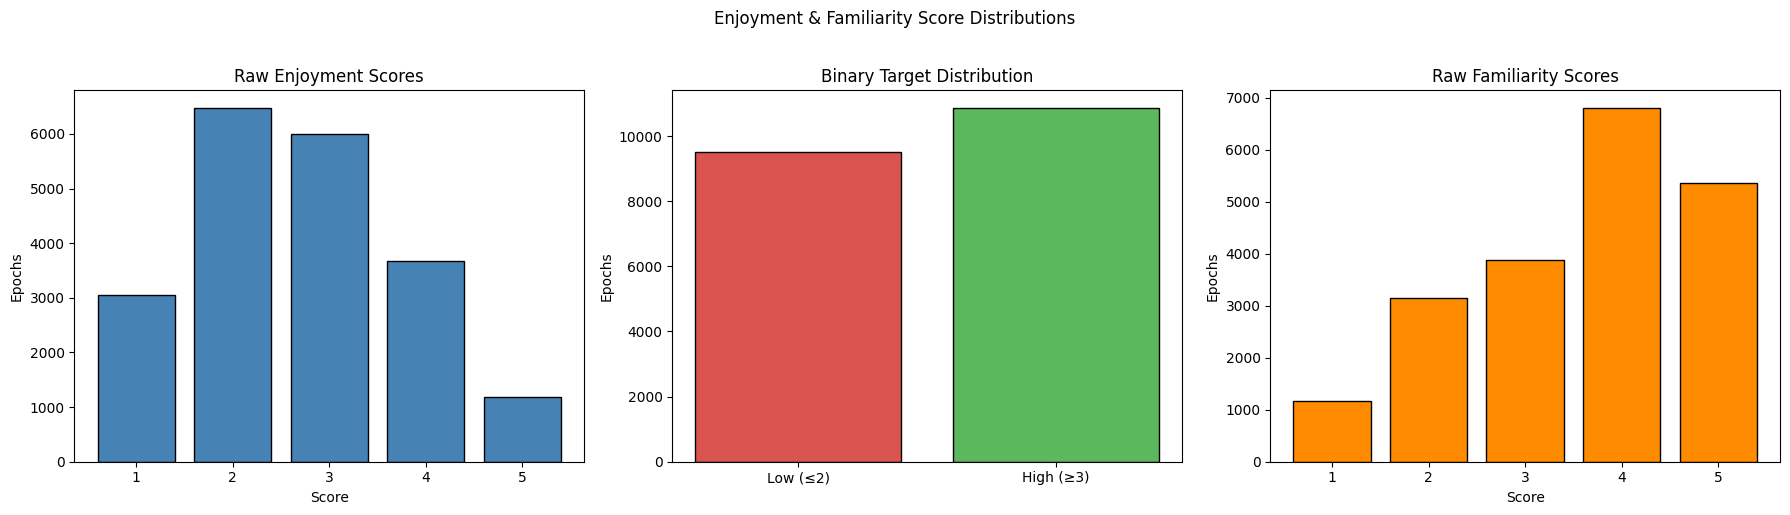

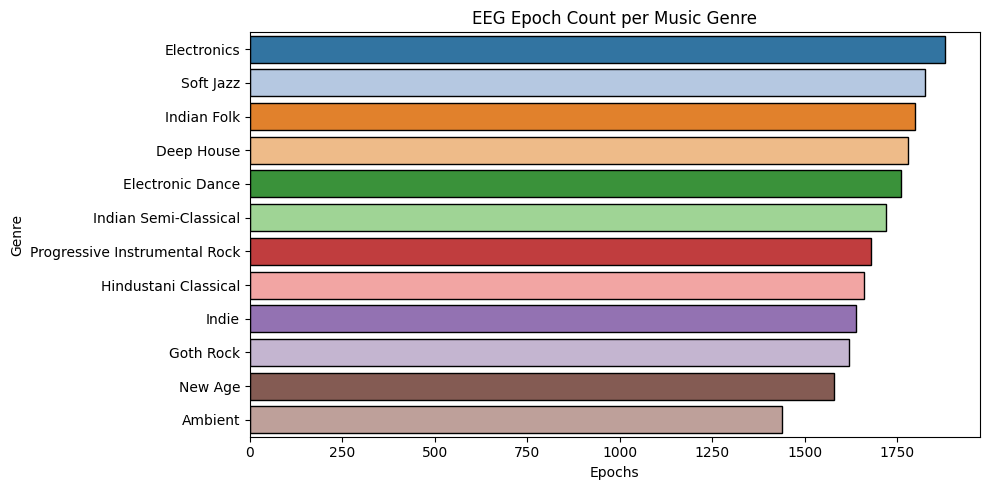

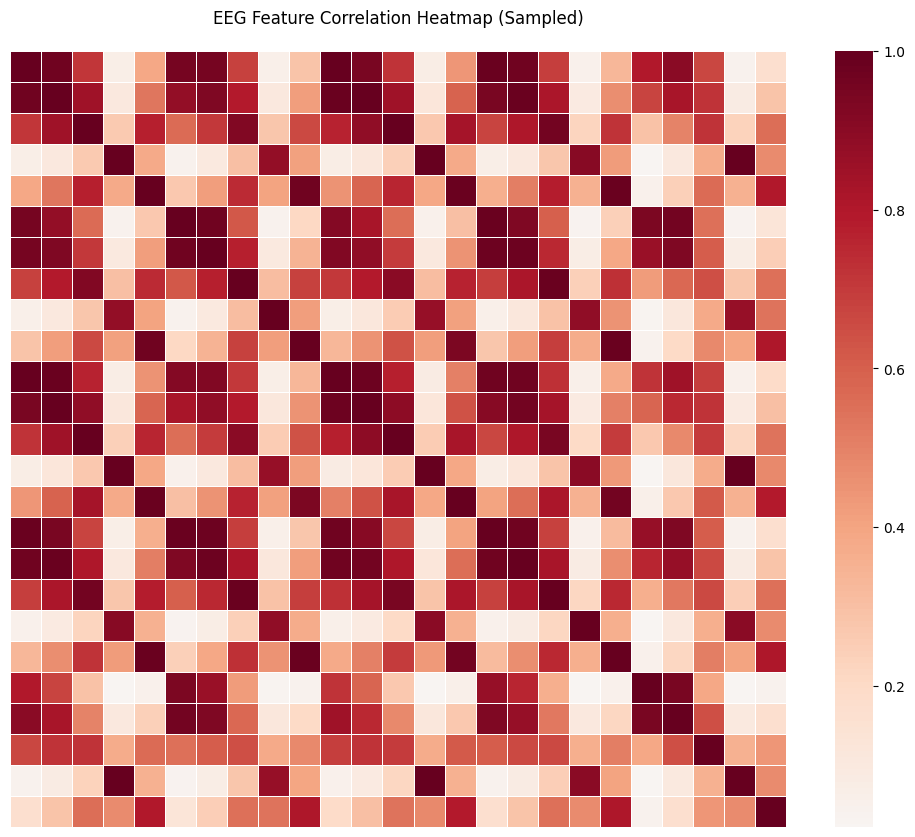

EDA complete. Figures exported to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN


In [ ]:
# descriptive statistics
def print_descriptive_stats(df):
    feature_cols = [c for c in df.columns if any(s in c for s in ['_abs', '_log', '_rel'])]
    desc = df[feature_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
    desc.columns = ['Mean', 'Std', 'Min', 'Q1', 'Median', 'Q3', 'Max']

    print("EEG Feature Descriptive Statistics (Sample)")
    display(desc.head(10))
    print(f"\nTotal tracked EEG features: {len(feature_cols)}\n")
    return feature_cols

# visualization functions
def plot_target_distributions(df, export_dir):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Enjoyment & Familiarity Score Distributions', fontsize=12, y=1.02)

    # raw enjoyment
    enjoy_counts = df['Enjoyment'].value_counts().sort_index()
    axes[0].bar(enjoy_counts.index, enjoy_counts.values, color='steelblue', edgecolor='black')
    axes[0].set(title='Raw Enjoyment Scores', xlabel='Score', ylabel='Epochs')

    # binary enjoyment
    binary_counts = df['enjoyment_binary'].value_counts().sort_index()
    binary_labels = ['Low (≤2)', 'High (≥3)']
    axes[1].bar(binary_labels, binary_counts.values, color=['#d9534f', '#5cb85c'], edgecolor='black')
    axes[1].set(title='Binary Target Distribution', ylabel='Epochs')

    # raw familiarity
    fam_counts = df['Familiarity'].value_counts().sort_index()
    axes[2].bar(fam_counts.index, fam_counts.values, color='darkorange', edgecolor='black')
    axes[2].set(title='Raw Familiarity Scores', xlabel='Score', ylabel='Epochs')

    plt.tight_layout()
    plt.savefig(f'{export_dir}/enjoyment_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_genre_distribution(df, export_dir):
    genre_counts = df['Genre'].value_counts()

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='tab20', edgecolor='black', ax=ax)
    ax.set(title='EEG Epoch Count per Music Genre', xlabel='Epochs', ylabel='Genre')

    plt.tight_layout()
    plt.savefig(f'{export_dir}/genre_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_correlation_heatmap(df, feature_cols, export_dir):
    sample_feats = [c for c in feature_cols if '_abs' in c][:25]
    corr_matrix = df[sample_feats].corr()

    fig, ax = plt.subplots(figsize=(10, 10))
    sns.heatmap(corr_matrix, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)

    ax.set_title('EEG Feature Correlation Heatmap (Sampled)', pad=20)
    plt.xticks([])
    plt.yticks([])

    plt.tight_layout()
    plt.savefig(f'{export_dir}/feature_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

# execute eda pipeline
eeg_feature_list = print_descriptive_stats(master_df)

print("Generating visualizations...")
plot_target_distributions(master_df, project_dir)
plot_genre_distribution(master_df, project_dir)
plot_correlation_heatmap(master_df, eeg_feature_list, project_dir)

print(f"EDA complete. Figures exported to: {project_dir}")

### 4. Missing Data Handling

This step scans the dataset for missing values (NaNs). If missing values are detected in numeric features, they are automatically imputed using the column median to preserve data distribution without introducing severe outliers.

In [ ]:
# missing data detection
print(" Missing Data Report")
missing = master_df.isna().sum()
missing_report = missing[missing > 0].reset_index()

if missing_report.empty:
    print("No missing values detected in the master dataset.")
else:
    missing_report.columns = ['column', 'missing_count']
    missing_report['missing_pct'] = (missing_report['missing_count'] / len(master_df) * 100).round(2)
    display(missing_report)

 Missing Data Report


,column,missing_count,missing_pct
0,Tempo(BPM),1580,7.75


In [ ]:
# targeted missing data imputation
print("Targeted Imputation Strategy")

# 1. impute Tempo(BPM) with Mean (due to normal distribution assumption)
if 'Tempo(BPM)' in master_df.columns and master_df['Tempo(BPM)'].isna().sum() > 0:
    mean_tempo = master_df['Tempo(BPM)'].mean()
    master_df['Tempo(BPM)'] = master_df['Tempo(BPM)'].fillna(mean_tempo)
    print(f"Imputed 'Tempo(BPM)' with mean: {mean_tempo:.2f}")

# 2. impute remaining numeric columns (mostly EEG) with Median (robust to outliers)
missing_remaining = master_df.isna().sum()
cols_to_impute = missing_remaining[missing_remaining > 0].index

for col in cols_to_impute:
    if master_df[col].dtype in [np.float64, np.int64]:
        median_val = master_df[col].median()
        master_df[col] = master_df[col].fillna(median_val)
        print(f"Imputed '{col}' with median: {median_val:.4f}")

total_after = master_df.isna().sum().sum()
print(f"\nTotal missing values after targeted imputation: {total_after} (Expected: 0)")

Targeted Imputation Strategy
Imputed 'Tempo(BPM)' with mean: 136.80

Total missing values after targeted imputation: 0 (Expected: 0)


### 5. Target Distribution Analysis

This section evaluates the class balance of the binary target variable (enjoyment_binary) to mathematically assess the need for synthetic oversampling (SMOTE) prior to model training.

In [ ]:
# class balance reporting
def print_class_balance(df, target_col):
    low_count = (df[target_col] == 0).sum()
    high_count = (df[target_col] == 1).sum()
    total = len(df)
    imbalance_ratio = max(low_count, high_count) / min(low_count, high_count)

    print("Binary Target Distribution:")
    print(f"Low Enjoyment (0) : {low_count:,} epochs ({100*low_count/total:.1f}%)")
    print(f"High Enjoyment (1): {high_count:,} epochs ({100*high_count/total:.1f}%)")
    print(f"Imbalance Ratio   : {imbalance_ratio:.2f}:1")

# execute target distribution analysis
print_class_balance(master_df, 'enjoyment_binary')

Binary Target Distribution:
Low Enjoyment (0) : 9,521 epochs (46.7%)
High Enjoyment (1): 10,861 epochs (53.3%)
Imbalance Ratio   : 1.14:1


### 6. Categorical Feature Encoding

This section applies mathematical encoding to categorical metadata (Label Encoding for Genre, One-Hot Encoding for Vocal Language) to ensure compatibility with downstream machine learning algorithms.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# categorical encoding
def encode_categorical_features(df):
    df_encoded = df.copy()

    # label encode genre (stored for reference/stratification)
    le = LabelEncoder()
    df_encoded['genre_encoded'] = le.fit_transform(df_encoded['Genre'])

    # store mapping for future reference
    genre_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Genre label encoding mapped successfully.")

    # one-hot encode vocal language
    if 'Vocal_Language' in df_encoded.columns:
        df_encoded = pd.get_dummies(df_encoded, columns=['Vocal_Language'], drop_first=True)

        # ensure integer type for dummy columns (prevents boolean warnings)
        ohe_cols = [c for c in df_encoded.columns if 'Vocal_Language_' in c]
        df_encoded[ohe_cols] = df_encoded[ohe_cols].astype(int)

        print(f"One-hot encoding applied. Added {len(ohe_cols)} dummy features.")
    else:
        print("'Vocal_Language' column not found. Skipping OHE.")

    return df_encoded, genre_mapping

# execute encoding
master_df, genre_map_dict = encode_categorical_features(master_df)
print(f"\nEncoding complete. Final master shape: {master_df.shape}")

Genre label encoding mapped successfully.
One-hot encoding applied. Added 3 dummy features.

Encoding complete. Final master shape: (20382, 1950)


### 7. Feature Matrix and Within-Subject Split

This section isolates the predictive continuous features (EEG data) from metadata. It then performs a standard stratified 80/20 data split. This represents the "Within-Subject" baseline, where the model learns the neural signatures of the subjects in the training Step and tests its generalization on unseen epochs from those same cognitive profiles.

In [ ]:
from sklearn.model_selection import train_test_split

# define columns to exclude from the feature matrix
cols_to_drop = [
    'Subject', 'Song_ID', 'Group_ID', 'epoch_id',
    'Genre', 'genre_encoded',
    'Enjoyment', 'Familiarity', 'enjoyment_binary',
    'Song_Name', 'Artist', 'Song No.', 'Duration(sec)',
    'Tempo(BPM)', 'Duration from Song'
]

# safely drop existing columns and object types
drop_existing = [c for c in cols_to_drop if c in master_df.columns]
obj_cols = master_df.drop(columns=drop_existing).select_dtypes(include='object').columns.tolist()
drop_existing.extend(obj_cols)

# define features (X), target (y), and preserve groups
x_full = master_df.drop(columns=drop_existing)
y_full = master_df['enjoyment_binary']
groups = master_df['Subject']

# perform within-subject stratified split (80/20)
all_indices = np.arange(len(x_full))
train_idx, test_idx = train_test_split(all_indices, test_size=0.20, random_state=42, stratify=y_full)

# construct train and test sets
x_train_ws = x_full.iloc[train_idx].reset_index(drop=True)
x_test_ws = x_full.iloc[test_idx].reset_index(drop=True)
y_train_ws = y_full.iloc[train_idx].reset_index(drop=True)
y_test_ws = y_full.iloc[test_idx].reset_index(drop=True)

# preserve group alignments
groups_train_ws = groups.iloc[train_idx].reset_index(drop=True)
groups_test_ws = groups.iloc[test_idx].reset_index(drop=True)

print(" Matrix Definition and Within-Subject Split Complete")
print(f"Feature matrix (X) shape: {x_full.shape}")
print(f"Target vector (y) shape : {y_full.shape}")

print("\nSplit Results (80/20):")
print(f"Train set : {x_train_ws.shape[0]:,} epochs | Class balance: {y_train_ws.value_counts().to_dict()}")
print(f"Test set  : {x_test_ws.shape[0]:,} epochs | Class balance: {y_test_ws.value_counts().to_dict()}")

# verify within-subject overlap (subjects must be present in both sets)
overlap = set(groups_train_ws).intersection(set(groups_test_ws))
print(f"\nSubject overlap (Train vs Test): {len(overlap)} subjects shared.")
print("High overlap confirms a successful 'Within-Subject' evaluation split.")

 Matrix Definition and Within-Subject Split Complete
Feature matrix (X) shape: (20382, 1938)
Target vector (y) shape : (20382,)

Split Results (80/20):
Train set : 16,305 epochs | Class balance: {1: 8688, 0: 7617}
Test set  : 4,077 epochs | Class balance: {1: 2173, 0: 1904}

Subject overlap (Train vs Test): 20 subjects shared.
High overlap confirms a successful 'Within-Subject' evaluation split.


### 8. Feature Scaling (Standardization)

This section applies standard scaling (z-score normalization) to the EEG feature matrix. To strictly prevent data leakage, the scaler is fitted exclusively on the training data and then utilized to transform both the training and test sets independently.

Executing Feature Standardization
StandardScaler applied successfully.
Verification on feature 'E1_Delta_abs':
Mean: 0.000000 (Expected: ~0.0)
Std : 1.000031  (Expected: ~1.0)


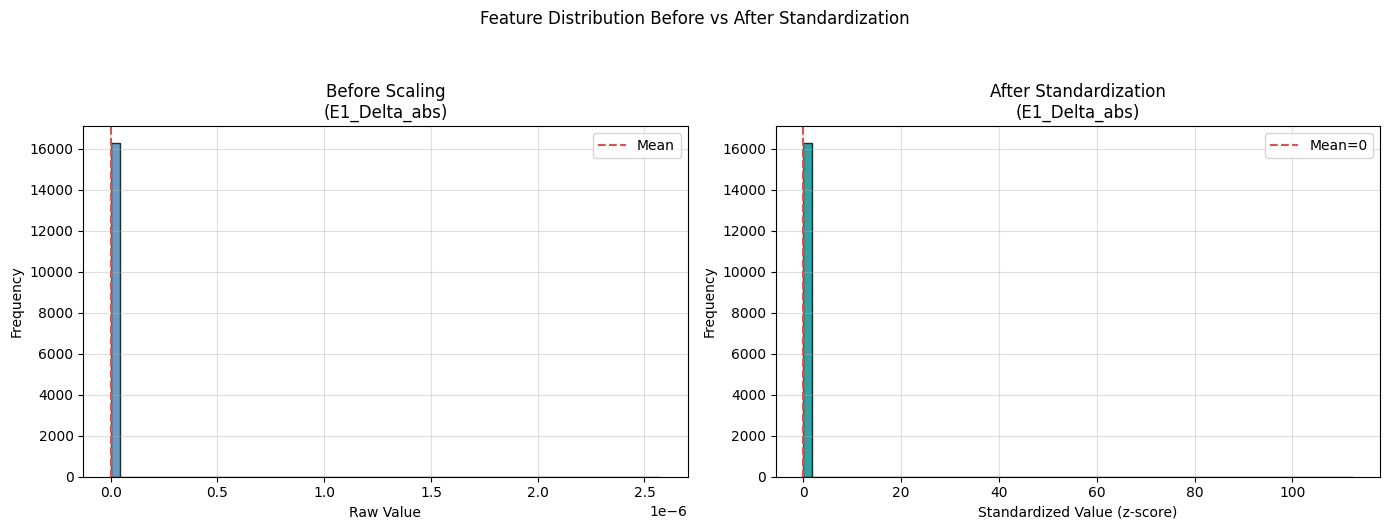


Scaling visualization exported to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN


In [ ]:
from sklearn.preprocessing import StandardScaler

# feature scaling function
def scale_features(x_train, x_test):
    scaler = StandardScaler()

    # fit and transform on train, only transform on test to prevent leakage
    x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
    x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

    return x_train_scaled, x_test_scaled, scaler

# visualization function for scaling effect
def plot_scaling_effect(raw_df, scaled_df, feature_name, export_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Feature Distribution Before vs After Standardization', fontsize=12, y=1.05)

    # before scaling
    axes[0].hist(raw_df[feature_name], bins=60, color='steelblue', edgecolor='black', alpha=0.8)
    axes[0].set(title=f'Before Scaling\n({feature_name})', xlabel='Raw Value', ylabel='Frequency')
    axes[0].axvline(raw_df[feature_name].mean(), color='#d9534f', linestyle='--', label='Mean')
    axes[0].legend()
    axes[0].grid(alpha=0.4)

    # after scaling
    axes[1].hist(scaled_df[feature_name], bins=60, color='darkcyan', edgecolor='black', alpha=0.8)
    axes[1].set(title=f'After Standardization\n({feature_name})', xlabel='Standardized Value (z-score)', ylabel='Frequency')
    axes[1].axvline(0, color='#d9534f', linestyle='--', label='Mean=0')
    axes[1].legend()
    axes[1].grid(alpha=0.4)

    plt.tight_layout()
    plt.savefig(f'{export_dir}/scaling_effect.png', dpi=150, bbox_inches='tight')
    plt.show()

# execute scaling
print("Executing Feature Standardization")

x_train_ws_scaled, x_test_ws_scaled, scaler_ws = scale_features(x_train_ws, x_test_ws)

# verify scaling mathematically
sample_col = x_train_ws_scaled.columns[0]
sample_mean = x_train_ws_scaled[sample_col].mean()
sample_std = x_train_ws_scaled[sample_col].std()

print(f"StandardScaler applied successfully.")
print(f"Verification on feature '{sample_col}':")
print(f"Mean: {sample_mean:.6f} (Expected: ~0.0)")
print(f"Std : {sample_std:.6f}  (Expected: ~1.0)")

# generate visualization
eeg_feature_for_plot = eeg_feature_list[0] if 'eeg_feature_list' in locals() else sample_col
plot_scaling_effect(x_train_ws, x_train_ws_scaled, eeg_feature_for_plot, project_dir)
print(f"\nScaling visualization exported to: {project_dir}")

### 9. Feature Selection and Ablation Study

This section performs frequency-band specific feature selection using ANOVA F-value (SelectKBest). An ablation study is first conducted to determine the optimal number of features (K) per band by evaluating intermediate subsets with a baseline Random Forest classifier. Finally, the optimized feature matrix is extracted and saved for model training.

Feature Selection Initiated

Ablation Study: K features per band vs Validation Accuracy
  K= 5/band | Total features:  25 | Accuracy: 0.7307
  K=10/band | Total features:  50 | Accuracy: 0.7400
  K=15/band | Total features:  75 | Accuracy: 0.7461
  K=20/band | Total features: 100 | Accuracy: 0.7550


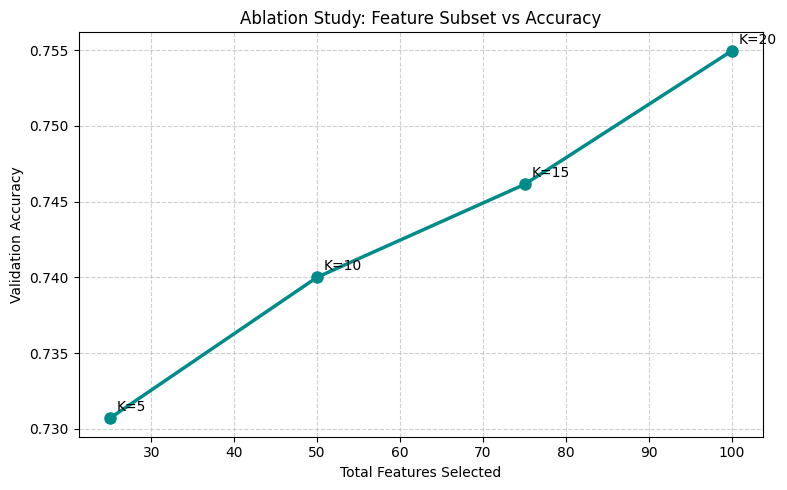


Executing Final Selection (K=20 per band)...
  Delta   :  20 features extracted
  Theta   :  20 features extracted
  Alpha   :  20 features extracted
  Beta    :  20 features extracted
  Gamma   :  20 features extracted


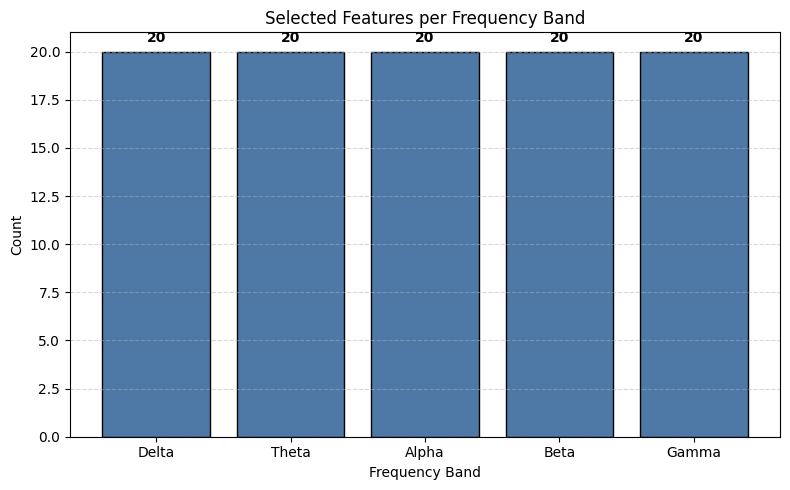


Step 9 Complete. Final feature matrix shape: (16305, 100)
Matrices exported to /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN for downstream classification.


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

# ablation study function
def run_ablation_study(x_train, y_train, x_test, y_test, bands, k_values):
    ablation_accs = []
    ablation_nfeats = []

    print("Ablation Study: K features per band vs Validation Accuracy")
    for k in k_values:
        temp_feats = []
        for band in bands:
            band_cols = [c for c in x_train.columns if f'_{band}_' in c]
            if not band_cols: continue

            sel = SelectKBest(score_func=f_classif, k=min(k, len(band_cols)))
            sel.fit(x_train[band_cols], y_train)
            temp_feats += [c for c, m in zip(band_cols, sel.get_support()) if m]

        xk_tr = x_train[temp_feats]
        xk_te = x_test[temp_feats]

        rfc = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        rfc.fit(xk_tr, y_train)
        acc = rfc.score(xk_te, y_test)

        ablation_accs.append(acc)
        ablation_nfeats.append(len(temp_feats))
        print(f"  K={k:2d}/band | Total features: {len(temp_feats):3d} | Accuracy: {acc:.4f}")

    return ablation_accs, ablation_nfeats

def plot_ablation_curve(n_feats, accs, k_values, export_dir):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(n_feats, accs, marker='o', linewidth=2.5, color='darkcyan', markersize=8)

    for x, y_val, k in zip(n_feats, accs, k_values):
        ax.annotate(f'K={k}', (x, y_val), textcoords='offset points', xytext=(5, 5), fontsize=10)

    ax.set(title='Ablation Study: Feature Subset vs Accuracy', xlabel='Total Features Selected', ylabel='Validation Accuracy')
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig(f'{export_dir}/ablation_feature_selection.png', dpi=150, bbox_inches='tight')
    plt.show()

# final feature selection function
def select_final_features(x_train, x_test, y_train, bands, k_final):
    selected_features = []
    band_feature_map = {}

    print(f"\nExecuting Final Selection (K={k_final} per band)...")
    for band in bands:
        band_cols = [c for c in x_train.columns if f'_{band}_' in c]
        if not band_cols: continue

        sel = SelectKBest(score_func=f_classif, k=min(k_final, len(band_cols)))
        sel.fit(x_train[band_cols], y_train)

        chosen = [c for c, m in zip(band_cols, sel.get_support()) if m]
        selected_features += chosen
        band_feature_map[band] = chosen
        print(f"  {band:<7} : {len(chosen):3d} features extracted")

    x_train_final = x_train[selected_features]
    x_test_final = x_test[selected_features]

    return x_train_final, x_test_final, selected_features, band_feature_map

def plot_features_per_band(band_map, export_dir):
    band_counts = {b: len(band_map[b]) for b in band_map}

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(band_counts.keys(), band_counts.values(), color='#4e79a7', edgecolor='black')
    ax.set(title='Selected Features per Frequency Band', xlabel='Frequency Band', ylabel='Count')

    for i, cnt in enumerate(band_counts.values()):
        ax.text(i, cnt + 0.5, str(cnt), ha='center', fontweight='bold')

    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'{export_dir}/features_per_band.png', dpi=150, bbox_inches='tight')
    plt.show()

# execute Step 9 pipeline
print("Feature Selection Initiated\n")

bands_list = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
k_test_values = [5, 10, 15, 20]
k_final_target = 20

# 1. run ablation
accs, nfeats = run_ablation_study(x_train_ws_scaled, y_train_ws, x_test_ws_scaled, y_test_ws, bands_list, k_test_values)
plot_ablation_curve(nfeats, accs, k_test_values, project_dir)

# 2. apply final selection
x_train_ws_final, x_test_ws_final, final_feats, band_map = select_final_features(x_train_ws_scaled, x_test_ws_scaled, y_train_ws, bands_list, k_final_target)
plot_features_per_band(band_map, project_dir)

# 3. export arrays for modeling
np.save(f'{project_dir}/x_train_ws_final.npy', x_train_ws_final.values)
np.save(f'{project_dir}/x_test_ws_final.npy', x_test_ws_final.values)
np.save(f'{project_dir}/y_train_ws.npy', y_train_ws.values)
np.save(f'{project_dir}/y_test_ws.npy', y_test_ws.values)

print(f"\nStep 9 Complete. Final feature matrix shape: {x_train_ws_final.shape}")
print(f"Matrices exported to {project_dir} for downstream classification.")

### 10. Machine Learning Classification (Within-Subject)

This section establishes the baseline predictive performance using five distinct machine learning algorithms. The models are trained on the optimal feature subset (selected via ANOVA) to classify binary music enjoyment. Performance is evaluated using standard metrics (Accuracy, F1-Score) and visualized via confusion matrices.

Model Training & Evaluation (Within-Subject)

  Logistic Regression  | Acc: 0.6490 | F1: 0.6479
  K-Nearest Neighbors  | Acc: 0.7334 | F1: 0.7333
  SVM (Linear)         | Acc: 0.6505 | F1: 0.6493
  Random Forest        | Acc: 0.7557 | F1: 0.7556
  XGBoost              | Acc: 0.7751 | F1: 0.7749

Model Comparison Results (Sorted by F1-Score):


,Model,Accuracy,Precision,Recall,F1-Score,Train_Time(s),Pred_Time/rec(ms)
0,XGBoost,0.775100,0.774900,0.775100,0.774900,8.978200,0.018100
1,Random Forest,0.755700,0.755500,0.755700,0.755600,51.646200,0.043100
2,K-Nearest Neighbors,0.733400,0.733300,0.733400,0.733300,0.011200,0.178100
3,SVM (Linear),0.650500,0.649600,0.650500,0.649300,387.308700,0.629700
4,Logistic Regression,0.649000,0.648100,0.649000,0.647900,2.824500,0.000700



Generating confusion matrices...


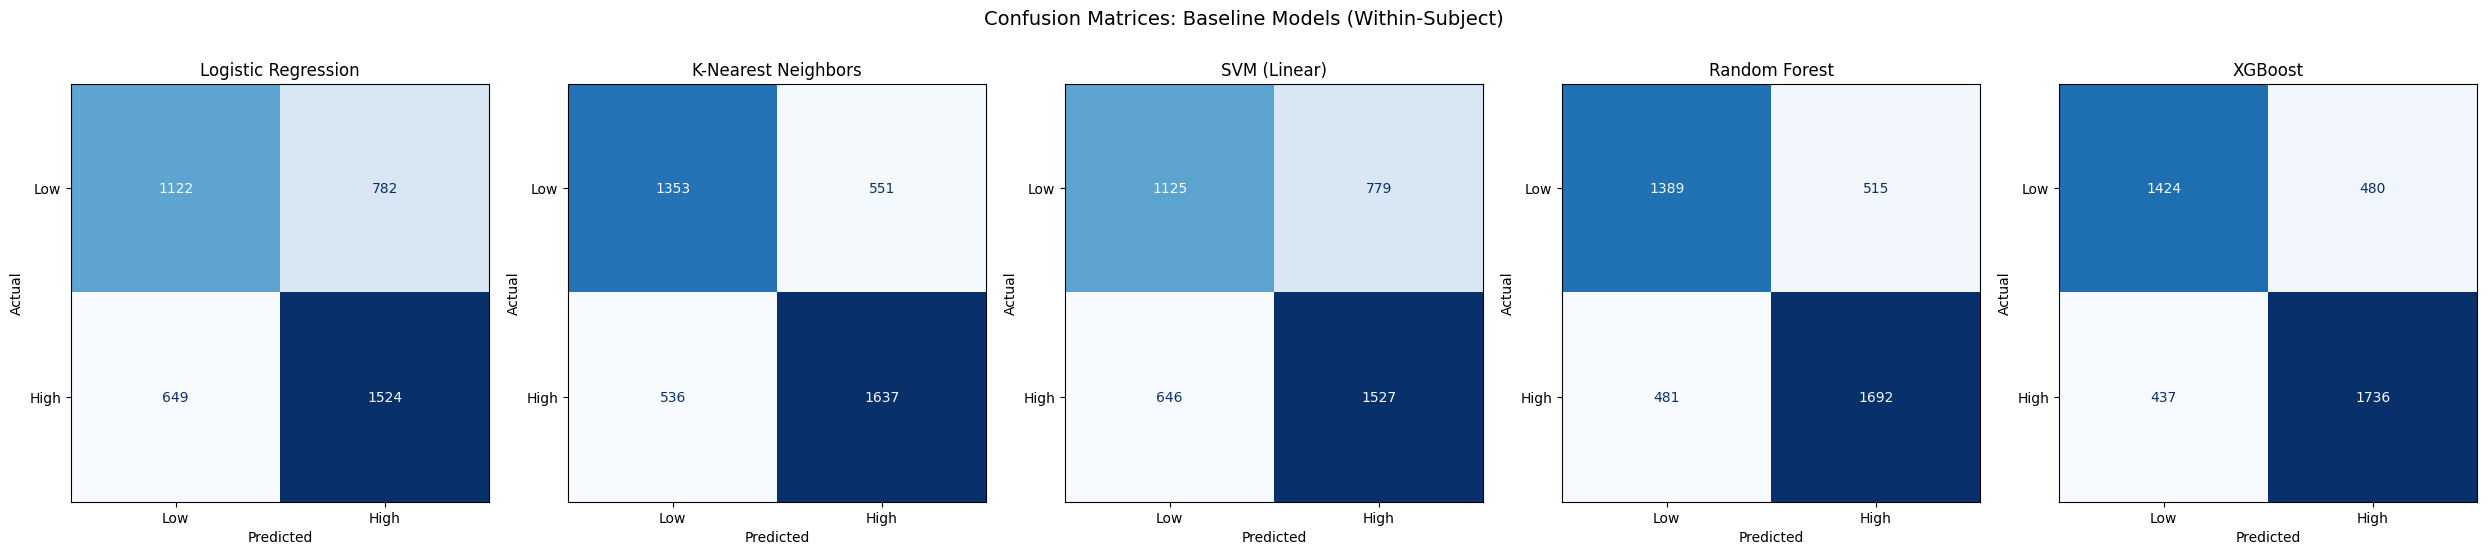

Confusion matrices exported to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# define machine learning algorithms with base hyperparameters
ml_models = {
    'Logistic Regression': LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean', n_jobs=-1),
    'SVM (Linear)': SVC(kernel='linear', C=1.0, probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=2, min_samples_leaf=1, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1)
}

# training and evaluation function
def train_and_evaluate_models(models_dict, x_train, y_train, x_test, y_test):
    results = []
    trained_models = {}

    for name, model in models_dict.items():
        # train
        t0_train = time.time()
        model.fit(x_train, y_train)
        t_train = time.time() - t0_train

        # predict
        t0_pred = time.time()
        y_pred = model.predict(x_test)
        t_pred_one = (time.time() - t0_pred) / len(x_test)

        # calculate metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        results.append({
            'Model': name,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4),
            'Train_Time(s)': round(t_train, 4),
            'Pred_Time/rec(ms)': round(t_pred_one * 1000, 4)
        })
        trained_models[name] = model
        print(f"  {name:<20} | Acc: {acc:.4f} | F1: {f1:.4f}")

    df_results = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
    return df_results, trained_models

# confusion matrix plotting function
def plot_confusion_matrices(trained_models, x_test, y_test, export_dir):
    fig, axes = plt.subplots(1, len(trained_models), figsize=(25, 5))
    fig.suptitle('Confusion Matrices: Baseline Models (Within-Subject)', fontsize=14, y=1.05)

    for ax, (name, model) in zip(axes, trained_models.items()):
        y_pred = model.predict(x_test)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'High'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set(title=name, xlabel='Predicted', ylabel='Actual')

    plt.tight_layout()
    plt.savefig(f'{export_dir}/confusion_matrices_ml.png', dpi=150, bbox_inches='tight')
    plt.show()

# execute classification pipeline
print("Model Training & Evaluation (Within-Subject)\n")

# note: inputs correspond to the arrays generated Step 9
df_results_ws, trained_models_ws = train_and_evaluate_models(
    ml_models, x_train_ws_final, y_train_ws, x_test_ws_final, y_test_ws
)

print("\nModel Comparison Results (Sorted by F1-Score):")
display(df_results_ws.style.background_gradient(cmap='Blues', subset=['Accuracy', 'F1-Score']))
print("\nGenerating confusion matrices...")
plot_confusion_matrices(trained_models_ws, x_test_ws_final, y_test_ws, project_dir)
print(f"Confusion matrices exported to: {project_dir}")

## 11. Cross-Subject Evaluation (20/80 Group Split)

To rigorously test model generalization on unseen cognitive profiles, this section performs a strict Cross-Subject evaluation. Utilizing GroupShuffleSplit, the dataset is strictly partitioned so that 20% of the subjects are used for training and 80% for testing, with zero subject overlap. The results are then benchmarked against the Within-Subject (80/20) baseline.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone

# cross-subject evaluation function
def run_cross_subject_evaluation(models_dict, x_train_features, y_train_target, groups_array):
    # strict isolation by Subject ID (GroupShuffleSplit ensures 0 overlap)
    gss_20 = GroupShuffleSplit(n_splits=1, train_size=0.20, random_state=42)

    # generate split indices
    for tr20_idx, te80_idx in gss_20.split(x_train_features, y_train_target, groups=groups_array):
        x_tr20 = x_train_features.iloc[tr20_idx]
        x_te80 = x_train_features.iloc[te80_idx]
        y_tr20 = y_train_target.iloc[tr20_idx]
        y_te80 = y_train_target.iloc[te80_idx]

    results_cs = []

    for name, orig_model in models_dict.items():
        # safely clone model to avoid weight contamination from previous step
        model_cs = clone(orig_model)

        # train on 20% unseen subjects
        t0 = time.time()
        model_cs.fit(x_tr20, y_tr20)
        t_train_cs = time.time() - t0

        # predict on 80% unseen subjects
        t0 = time.time()
        y_pred_cs = model_cs.predict(x_te80)
        t_pred_one_cs = (time.time() - t0) / len(x_te80)

        # metrics
        acc_cs = accuracy_score(y_te80, y_pred_cs)
        f1_cs  = f1_score(y_te80, y_pred_cs, average='weighted', zero_division=0)

        results_cs.append({
            'Model': name,
            'Acc_Cross (20/80)': round(acc_cs, 4),
            'F1_Cross (20/80)': round(f1_cs, 4),
            'Train Time_CS (s)': round(t_train_cs, 4),
            'Pred Time_CS/rec (ms)': round(t_pred_one_cs * 1000, 4)
        })
        print(f" {name:<20} | Acc: {acc_cs:.4f} | F1: {f1_cs:.4f}")

    return pd.DataFrame(results_cs)

# comparison table generator
def generate_comparison_table(df_ws, df_cs):
    # build a clean comparison dataframe
    df_compare = pd.DataFrame({
        'Model': df_ws['Model'],
        'Acc_Within (80/20)': df_ws['Accuracy'],
        'Acc_Cross (20/80)': df_ws['Model'].map(df_cs.set_index('Model')['Acc_Cross (20/80)']),
        'F1_Within (80/20)': df_ws['F1-Score'],
        'F1_Cross (20/80)': df_ws['Model'].map(df_cs.set_index('Model')['F1_Cross (20/80)']),
        'Train_Time_WS (s)': df_ws['Train_Time(s)'],
        'Train_Time_CS (s)': df_ws['Model'].map(df_cs.set_index('Model')['Train Time_CS (s)'])
    })
    return df_compare

# execute Step 11 pipeline
print("Model Training & Evaluation (Cross-Subject 20/80)\n")

# groups_train_ws was defined in Step 7 to preserve the subject groupings
df_results_cs = run_cross_subject_evaluation(ml_models, x_train_ws_final, y_train_ws, groups_train_ws)

print("\nExecuting Final Benchmark Comparison...")
df_comparison = generate_comparison_table(df_results_ws, df_results_cs)

print("\nModel Performance Comparison: Within-Subject vs Cross-Subject")
display(df_comparison.style.background_gradient(cmap='Purples', subset=['Acc_Within (80/20)', 'Acc_Cross (20/80)', 'F1_Within (80/20)', 'F1_Cross (20/80)']))

Model Training & Evaluation (Cross-Subject 20/80)

 Logistic Regression  | Acc: 0.5110 | F1: 0.4898
 K-Nearest Neighbors  | Acc: 0.5294 | F1: 0.5303
 SVM (Linear)         | Acc: 0.5138 | F1: 0.4871
 Random Forest        | Acc: 0.5335 | F1: 0.5230
 XGBoost              | Acc: 0.5292 | F1: 0.5249

Executing Final Benchmark Comparison...

Model Performance Comparison: Within-Subject vs Cross-Subject


,Model,Acc_Within (80/20),Acc_Cross (20/80),F1_Within (80/20),F1_Cross (20/80),Train_Time_WS (s),Train_Time_CS (s)
0,XGBoost,0.775100,0.529200,0.774900,0.524900,8.978200,6.033000
1,Random Forest,0.755700,0.533500,0.755600,0.523000,51.646200,6.831000
2,K-Nearest Neighbors,0.733400,0.529400,0.733300,0.530300,0.011200,0.005300
3,SVM (Linear),0.650500,0.513800,0.649300,0.487100,387.308700,9.599500
4,Logistic Regression,0.649000,0.511000,0.647900,0.489800,2.824500,2.308200


### 12. Synthetic Minority Over-sampling (SMOTE)

To address the class imbalance identified during the exploratory Step, SMOTE is applied exclusively to the training set. The highest-performing classifier from the baseline evaluation is then retrained on the balanced dataset. The effect of synthetic oversampling is quantified by comparing the F1-Score and confusion matrices before and after application.

Initiating SMOTE Pipeline

Executing SMOTE Optimization on Top Performing Model: XGBoost

Class distribution BEFORE SMOTE:
Low (0) : 7,617
High (1): 8,688

Class distribution AFTER SMOTE:
Low (0) : 8,688
High (1): 8,688

SMOTE Performance Summary:
Baseline F1-Score : 0.7749
Optimized (SMOTE) F1-Score: 0.7753
Net Change        : +0.0004


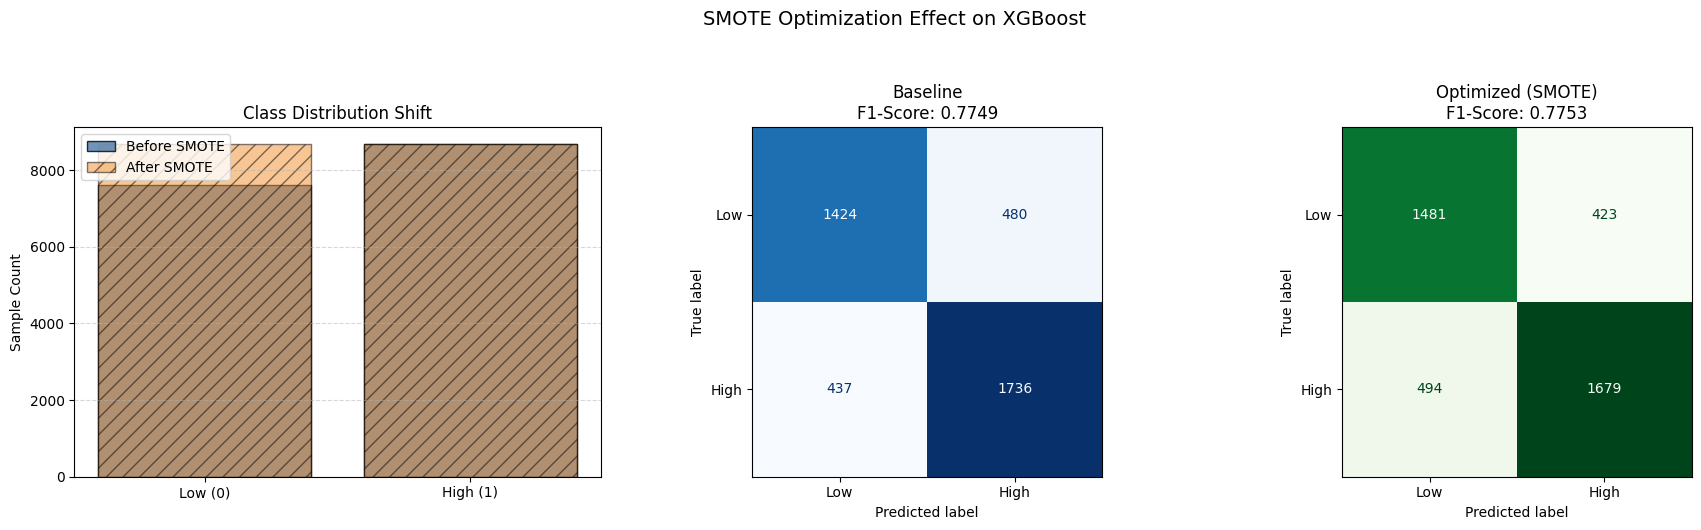


Optimization complete. Comparison figures exported to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.base import clone

# smote optimization and evaluation function
def evaluate_smote_effect(best_model_name, models_dict, trained_models, x_train, y_train, x_test, y_test):
    print(f"Executing SMOTE Optimization on Top Performing Model: {best_model_name}\n")

    # class distribution before
    before_counts = pd.Series(y_train).value_counts().sort_index()
    print("Class distribution BEFORE SMOTE:")
    print(f"Low (0) : {before_counts.get(0, 0):,}")
    print(f"High (1): {before_counts.get(1, 0):,}")

    # apply smote
    smote = SMOTE(random_state=42, k_neighbors=5)
    x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

    after_counts = pd.Series(y_train_smote).value_counts().sort_index()
    print("\nClass distribution AFTER SMOTE:")
    print(f"Low (0) : {after_counts.get(0, 0):,}")
    print(f"High (1): {after_counts.get(1, 0):,}")

    # evaluate baseline (before smote) - fetched directly from previous step memory
    model_before = trained_models[best_model_name]
    y_pred_before = model_before.predict(x_test)
    cm_before = confusion_matrix(y_test, y_pred_before)
    f1_before = f1_score(y_test, y_pred_before, average='weighted', zero_division=0)

    # train and evaluate optimized model (after smote)
    model_after = clone(models_dict[best_model_name])
    model_after.fit(x_train_smote, y_train_smote)
    y_pred_after = model_after.predict(x_test)
    cm_after = confusion_matrix(y_test, y_pred_after)
    f1_after = f1_score(y_test, y_pred_after, average='weighted', zero_division=0)

    # store optimized model back into the dictionary for potential future use (like ROC curves)
    trained_models[f'{best_model_name} (SMOTE)'] = model_after

    return before_counts, after_counts, cm_before, cm_after, f1_before, f1_after

def plot_smote_comparison(best_name, counts_before, counts_after, cm_bef, cm_aft, f1_bef, f1_aft, export_dir):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'SMOTE Optimization Effect on {best_name}', fontsize=14, y=1.05)

    # bar chart: class counts
    x_labels = ['Low (0)', 'High (1)']
    axes[0].bar(x_labels, [counts_before.get(0,0), counts_before.get(1,0)],
                color='#4e79a7', edgecolor='black', alpha=0.8, label='Before SMOTE')
    axes[0].bar(x_labels, [counts_after.get(0,0), counts_after.get(1,0)],
                color='#f28e2b', edgecolor='black', alpha=0.5, hatch='//', label='After SMOTE')
    axes[0].set(title='Class Distribution Shift', ylabel='Sample Count')
    axes[0].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # confusion matrix before
    ConfusionMatrixDisplay(cm_bef, display_labels=['Low','High']).plot(ax=axes[1], colorbar=False, cmap='Blues')
    axes[1].set_title(f'Baseline\nF1-Score: {f1_bef:.4f}')

    # confusion matrix after
    ConfusionMatrixDisplay(cm_aft, display_labels=['Low','High']).plot(ax=axes[2], colorbar=False, cmap='Greens')
    axes[2].set_title(f'Optimized (SMOTE)\nF1-Score: {f1_aft:.4f}')

    plt.tight_layout()
    plt.savefig(f'{export_dir}/smote_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# execute Step 12 pipeline
print("Initiating SMOTE Pipeline\n")

# dynamically identify the best model from Step 10 results
top_model_name = df_results_ws.iloc[0]['Model']

# run optimization
c_bef, c_aft, mat_bef, mat_aft, score_bef, score_aft = evaluate_smote_effect(
    top_model_name, ml_models, trained_models_ws,
    x_train_ws_final, y_train_ws, x_test_ws_final, y_test_ws
)

print("\nSMOTE Performance Summary:")
print(f"Baseline F1-Score : {score_bef:.4f}")
print(f"Optimized (SMOTE) F1-Score: {score_aft:.4f}")
print(f"Net Change        : {score_aft - score_bef:+.4f}")

# export visual proof
plot_smote_comparison(top_model_name, c_bef, c_aft, mat_bef, mat_aft, score_bef, score_aft, project_dir)
print(f"\nOptimization complete. Comparison figures exported to: {project_dir}")

### 13. ROC Curve Analysis and Final Evaluation

This final section visualizes the Receiver Operating Characteristic (ROC) curves for all trained models, including the SMOTE-optimized variant. The Area Under the Curve (AUC) is calculated to provide a definitive metric of each model's capability to distinguish between low and high music enjoyment states, independent of classification thresholds.

Generating ROC Curves and AUC Metrics



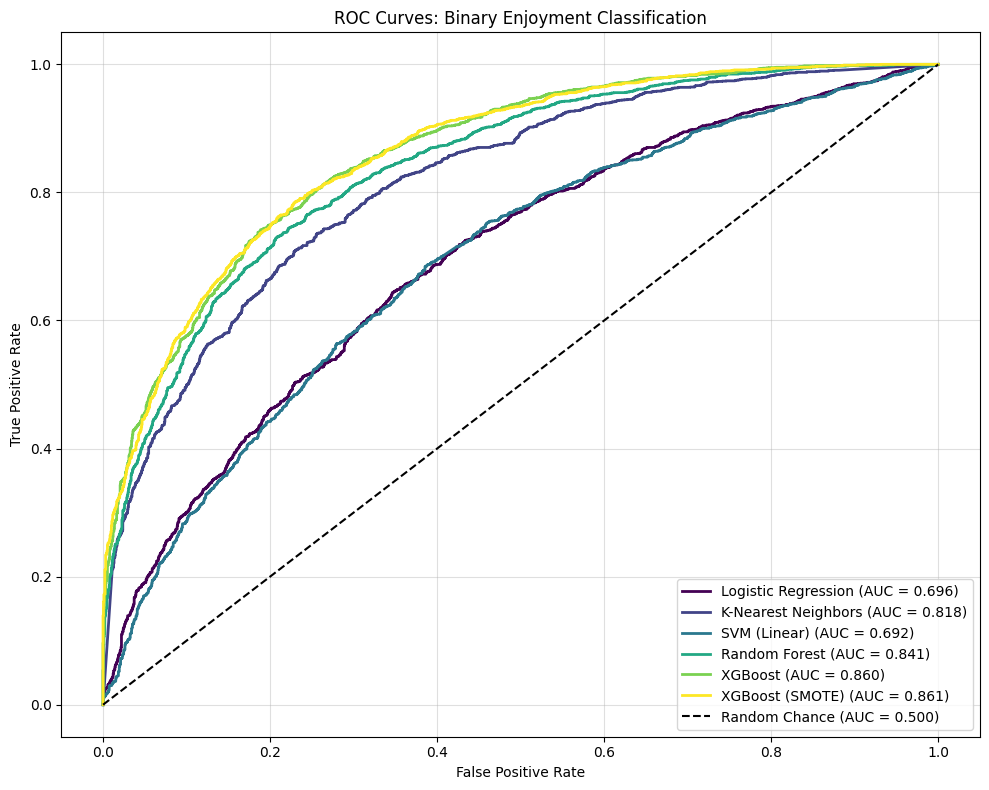

Final Model Comparison (Including AUC):


,Model,Accuracy,Precision,Recall,F1-Score,Train_Time(s),Pred_Time/rec(ms),AUC
0,XGBoost,0.775100,0.774900,0.775100,0.774900,8.978200,0.018100,0.860400
1,Random Forest,0.755700,0.755500,0.755700,0.755600,51.646200,0.043100,0.841300
2,K-Nearest Neighbors,0.733400,0.733300,0.733400,0.733300,0.011200,0.178100,0.817700
3,SVM (Linear),0.650500,0.649600,0.650500,0.649300,387.308700,0.629700,0.691900
4,Logistic Regression,0.649000,0.648100,0.649000,0.647900,2.824500,0.000700,0.696400



Optimization Result -> XGBoost (SMOTE) AUC: 0.8615

ROC curves exported to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN

Machine Learning Pipeline Completed Successfully.


In [ ]:
from sklearn.metrics import roc_curve, auc

# roc curve plotting and auc calculation function
def evaluate_and_plot_roc(trained_models_dict, x_test, y_test, df_results, export_dir):
    fig, ax = plt.subplots(figsize=(10, 8))

    colors = plt.cm.viridis(np.linspace(0, 1, len(trained_models_dict)))
    auc_results = {}

    for (name, model), color in zip(trained_models_dict.items(), colors):
        # dynamically extract probabilities based on algorithm type
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(x_test)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_score = model.decision_function(x_test)
        else:
            continue

        # calculate fpr, tpr and area under curve
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        auc_results[name] = round(roc_auc, 4)

        # plot individual model curves
        ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

    # plot random chance baseline (diagonal)
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')

    ax.set(title='ROC Curves: Binary Enjoyment Classification', xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.4)

    plt.tight_layout()
    plt.savefig(f'{export_dir}/roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    # append AUC metric to the main performance dataframe
    df_results['AUC'] = df_results['Model'].map(auc_results)

    return df_results, auc_results

# execute Step 13 pipeline
print("Generating ROC Curves and AUC Metrics\n")

df_results_final, all_auc_scores = evaluate_and_plot_roc(
    trained_models_ws, x_test_ws_final, y_test_ws, df_results_ws, project_dir
)

print("Final Model Comparison (Including AUC):")
display(df_results_final.style.background_gradient(cmap='Greens', subset=['Accuracy', 'F1-Score', 'AUC']))

# highlight the smote optimized model's AUC separately
smote_model_key = [k for k in all_auc_scores.keys() if 'SMOTE' in k]
if smote_model_key:
    smote_name = smote_model_key[0]
    print(f"\nOptimization Result -> {smote_name} AUC: {all_auc_scores[smote_name]:.4f}")

print(f"\nROC curves exported to: {project_dir}")
print("\nMachine Learning Pipeline Completed Successfully.")

### 14. Model Hyperparameters

This section extracts and formats the key hyperparameters configured for the baseline machine learning algorithms. Documenting these parameters ensures experimental reproducibility and provides transparency for the comparative analysis. Default technical parameters (e.g., random seeds, job allocations) are filtered out for reporting clarity.

In [ ]:
import pandas as pd


# hyperparameter extraction and table formatting
def display_model_hyperparameters(models_dict):
    param_rows = []
    ignore_keys = [
        "n_jobs",
        "verbose",
        "random_state",
        "use_label_encoder",
        "bootstrap",
    ]

    for name, model in models_dict.items():
        params = model.get_params()

        param_str = ", ".join(
            f"{k}={v}"
            for k, v in params.items()
            if v is not None and k not in ignore_keys
        )

        param_rows.append({"Model": name, "Key Hyperparameters": param_str})

    # create dataFrame
    df_params = pd.DataFrame(param_rows)
    return df_params

pd.set_option("display.max_colwidth", None)
# execute extraction
print("Baseline Model Hyperparameters\n")
df_params = display_model_hyperparameters(ml_models)

df_params

Baseline Model Hyperparameters



,Model,Key Hyperparameters
0,Logistic Regression,"C=1.0, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=1000, multi_class=deprecated, penalty=l2, solver=lbfgs, tol=0.0001, warm_start=False"
1,K-Nearest Neighbors,"algorithm=auto, leaf_size=30, metric=euclidean, n_neighbors=7, p=2, weights=distance"
2,SVM (Linear),"C=1.0, break_ties=False, cache_size=200, coef0=0.0, decision_function_shape=ovr, degree=3, gamma=scale, kernel=linear, max_iter=-1, probability=True, shrinking=True, tol=0.001"
3,Random Forest,"ccp_alpha=0.0, criterion=gini, max_depth=20, max_features=sqrt, min_impurity_decrease=0.0, min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.0, n_estimators=200, oob_score=False, warm_start=False"
4,XGBoost,"objective=binary:logistic, colsample_bytree=0.8, enable_categorical=False, eval_metric=logloss, learning_rate=0.1, max_depth=6, missing=nan, n_estimators=200, subsample=0.8"


### 15. Model Serialization and Artifact Export

This final section serializes the trained machine learning models, the fitted feature scaler, and the optimized ANOVA feature list using joblib. Exporting these artifacts ensures experimental persistence and reproducibility. A quick serialization test is executed to verify that the saved models can be successfully reloaded and utilized for inference without structure or data contamination.

In [ ]:
import joblib

# define or fallback model directory
model_export_dir = locals().get('MODEL_DIR', locals().get('model_dir', project_dir))

print("Serializing and Exporting Artifacts\n")

# 1. safely serialize all trained models from Step 10 & 12
for name, model in trained_models_ws.items():
    # clean string characters for safe cross-platform file paths
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '')
    path = f'{model_export_dir}/{safe_name}.pkl'

    joblib.dump(model, path)
    print(f"Saved Model : {path}")

# 2. serialize the scaler and the selected feature list to guarantee exact replication during inference
joblib.dump(scaler_ws, f'{model_export_dir}/scaler.pkl')
joblib.dump(final_feats, f'{model_export_dir}/selected_features.pkl')
print(f"Saved Scaler: {model_export_dir}/scaler.pkl")
print(f"Saved Features List: {model_export_dir}/selected_features.pkl")

# 3. quick load test (sanity check) on the saved Random Forest model
try:
    loaded_rf = joblib.load(f'{model_export_dir}/Random_Forest.pkl')
    test_pred = loaded_rf.predict(x_test_ws_final[:1])
    pred_label = 'High Enjoyment' if test_pred[0] == 1 else 'Low Enjoyment'
    print(f"\nLoad Test Passed: Random Forest reloaded successfully.")
    print(f"Sample Prediction on 1 record: {pred_label}")
except Exception as e:
    print(f"\nWarning during load test: {str(e)}")

print("NOTEBOOK 02: MACHINE LEARNING PIPELINE COMPLETED")
print(f"Feature Arrays Saved : x_train_ws_final.npy, x_test_ws_final.npy")
print(f"Labels Saved         : y_train_ws.npy, y_test_ws.npy")
print(f"Model Artifacts Dir  : {model_export_dir}/")
print(f"Visual Figures Dir   : {project_dir}/")
print("\nPipeline execution fully finalized. Proceed to Notebook 03 for Deep Learning Modeling.")

Serializing and Exporting Artifacts

Saved Model : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/Logistic_Regression.pkl
Saved Model : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/K-Nearest_Neighbors.pkl
Saved Model : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/SVM_Linear.pkl
Saved Model : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/Random_Forest.pkl
Saved Model : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/XGBoost.pkl
Saved Model : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/XGBoost_SMOTE.pkl
Saved Scaler: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/scaler.pkl
Saved Features List: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/selected_features.pkl

Load Test Passed: Random Forest reloaded successfully.
Sample Prediction on 1 record: Low Enjoyment
NOTEBOOK 02: MACHINE LEARNING PIPELINE COMPLETED
Feature Arrays Saved : x_train_ws_final.npy, x_test_ws_final.npy
Labels Saved         : y_train_ws.npy, y_test_ws.npy
Model Artifacts 